## Walmart-ის გაყიდვების პროგნოზირება — LightGBM

| Field | Details |
|---|---|
| **მოდელი** | LightGBM Regressor |
| **კატეგორია** | Tree-based — Gradient Boosting, leaf-wise growth |
| **MLflow ექსპერიმენტი** | `LightGBM_Training` |
| **მეტრიკა** | WMAE — სადღესასწაულო კვირებს ენიჭებათ 5-მაგი წონა |

---

### Runs

| Run | აღწერა |
|---|---|
| `LightGBM_Cleaning` | Preprocessing pipeline-ის ვალიდაცია |
| `LightGBM_Feature_Selection` | Feature ნაკრებების შედარება |
| `LightGBM_CrossValidation` | ქროს ვალიდაცია — TimeSeriesSplit CV |
| `LightGBM_HyperparameterTuning` | ჰიპერპარამეტრების tuning Optuna-ს გამოყენებით |
| `LightGBM_Final` | საუკეთესო pipeline (raw მონაცემებიდან prediction-მდე) |

---

### LightGBM vs XGBoost

| მახასიათებელი | LightGBM | XGBoost |
|---|---|---|
| **ხის ზრდა** | Leaf-wise (best-first) | Level-wise |
| **ალგორითმი** | ჰისტოგრამებზე დაფუძნებული — ნატიური | `tree_method='hist'` ცალკე უნდა მიეთითოს |
| **კატეგორიული ცვლადები** | Native მხარდაჭერა | One-Hot Encoding საჭიროა |
| **მეხსიერება** | გაცილებით ეფექტური | შედარებით მეტს მოიხმარს |
| **სიჩქარე** | უფრო სწრაფი დიდ datasets-ებზე | შედარებით ნელი |

---

### მოლოდინი

Walmart-ის მონაცემებზე ველით XGBoost-ის მსგავს ან მასზე ოდნავ უკეთეს შედეგს.

## 1. Setup

In [ ]:
!pip install lightgbm mlflow dagshub optuna --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import TimeSeriesSplit

import lightgbm as lgb
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

import optuna

print(f"LightGBM version: {lgb.__version__}")
print(f"MLflow version: {mlflow.__version__}")

LightGBM version: 4.6.0
MLflow version: 3.14.0


In [ ]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/walmart'
DATA_DIR = f'{PROJECT_DIR}/data'
MODELS_DIR = f'{PROJECT_DIR}/models'

import os
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR}")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/walmart/data


In [ ]:
# DagsHub + MLflow setup
import dagshub

DAGSHUB_USERNAME = "zberi23"
DAGSHUB_REPO = "walmart-forecasting"

dagshub.init(repo_owner=DAGSHUB_USERNAME, repo_name=DAGSHUB_REPO, mlflow=True)

EXPERIMENT_NAME = "LightGBM_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=0f0e3ca7-9aba-4d16-b110-7fdc83de385b&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=9299273bd823331855fbbbdf0938c17b703bac180698a8df0eaa1b6e10af3c6a




Accessing as gbera23-dev

Initialized MLflow to track repo "zberi23/walmart-forecasting"

Repository zberi23/walmart-forecasting initialized!

2026/07/11 14:32:25 INFO mlflow.tracking.fluent: Experiment with name 'LightGBM_Training' does not exist. Creating a new experiment.


MLflow tracking URI: https://dagshub.com/zberi23/walmart-forecasting.mlflow
Experiment: LightGBM_Training


## 2. Raw Data Loading

Pipeline იმუშავებს raw test set-ზე. სამივე original ფაილს ვტვირთავთ.

In [ ]:
train_raw = pd.read_csv(f'{DATA_DIR}/train.csv.zip')
test_raw = pd.read_csv(f'{DATA_DIR}/test.csv.zip')
stores_raw = pd.read_csv(f'{DATA_DIR}/stores.csv')
features_raw = pd.read_csv(f'{DATA_DIR}/features.csv.zip')

for df in [train_raw, test_raw, features_raw]:
    df['Date'] = pd.to_datetime(df['Date'])

print(f"Train raw: {train_raw.shape}")
print(f"Test raw:  {test_raw.shape}")
print(f"Stores:    {stores_raw.shape}")
print(f"Features:  {features_raw.shape}")

train_raw.head(3)

Train raw: (421570, 5)
Test raw:  (115064, 4)
Stores:    (45, 3)
Features:  (8190, 12)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False


## 3. Custom Preprocessor

იგივე Custom Transformer რაც XGBoost-ისთვის — raw CSV-ს გარდაქმნის მოდელისთვის მზა ფიჩერებად. Pipeline-ის შიგნით ჩაშენდება.

In [ ]:
class WalmartPreprocessor(BaseEstimator, TransformerMixin):
    """Custom Pipeline transformer — raw Walmart CSV → feature matrix."""

    def __init__(self, stores_df, features_df):
        self.stores_df = stores_df.copy()
        self.features_df = features_df.copy()
        if not pd.api.types.is_datetime64_any_dtype(self.features_df['Date']):
            self.features_df['Date'] = pd.to_datetime(self.features_df['Date'])

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        if not pd.api.types.is_datetime64_any_dtype(df['Date']):
            df['Date'] = pd.to_datetime(df['Date'])

        # Merge
        df = df.merge(self.features_df, on=['Store', 'Date', 'IsHoliday'], how='left')
        df = df.merge(self.stores_df, on='Store', how='left')

        # Missing values
        for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
            df[col] = df[col].fillna(0)
        for col in ['CPI', 'Unemployment']:
            df[col] = df.groupby('Store')[col].transform(
                lambda x: x.fillna(method='ffill').fillna(method='bfill')
            )

        # Date features
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
        df['Day_of_Year'] = df['Date'].dt.dayofyear
        df['Quarter'] = df['Date'].dt.quarter

        # Holiday flags
        super_bowl = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
        labor_day = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
        thanksgiving = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
        christmas = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

        df['Is_SuperBowl'] = df['Date'].isin(super_bowl).astype(int)
        df['Is_LaborDay'] = df['Date'].isin(labor_day).astype(int)
        df['Is_Thanksgiving'] = df['Date'].isin(thanksgiving).astype(int)
        df['Is_Christmas'] = df['Date'].isin(christmas).astype(int)

        # Cyclical
        df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
        df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)
        df['Week_Sin'] = np.sin(2 * np.pi * df['Week'] / 52)
        df['Week_Cos'] = np.cos(2 * np.pi * df['Week'] / 52)

        # Categorical
        type_mapping = {'A': 0, 'B': 1, 'C': 2}
        df['Type_Encoded'] = df['Type'].map(type_mapping)
        df['IsHoliday'] = df['IsHoliday'].astype(int)

        df = df.drop(columns=['Date', 'Type'])
        return df


# ტესტი
preprocessor = WalmartPreprocessor(stores_raw, features_raw)
X_test_transformed = preprocessor.fit_transform(test_raw)
print(f"Test raw: {test_raw.shape} → Transformed: {X_test_transformed.shape}")
print(f"Columns: {list(X_test_transformed.columns)}")

Test raw: (115064, 4) → Transformed: (115064, 27)
Columns: ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Day_of_Year', 'Quarter', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas', 'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos', 'Type_Encoded']


## 4. WMAE Metric + Train/Val Split

In [ ]:
def wmae(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def get_weights(is_holiday):
    return np.where(is_holiday == 1, 5, 1)


# Time-based split — ბოლო 10% val
train_sorted = train_raw.sort_values('Date').reset_index(drop=True)
split_date = train_sorted['Date'].quantile(0.9)

X_train_raw = train_sorted[train_sorted['Date'] < split_date].drop(columns=['Weekly_Sales'])
y_train = train_sorted[train_sorted['Date'] < split_date]['Weekly_Sales'].values

X_val_raw = train_sorted[train_sorted['Date'] >= split_date].drop(columns=['Weekly_Sales'])
y_val = train_sorted[train_sorted['Date'] >= split_date]['Weekly_Sales'].values

print(f"Train: {X_train_raw.shape}, Val: {X_val_raw.shape}")
print(f"Train dates: {X_train_raw['Date'].min()} → {X_train_raw['Date'].max()}")
print(f"Val dates:   {X_val_raw['Date'].min()} → {X_val_raw['Date'].max()}")

Train: (377155, 4), Val: (44415, 4)
Train dates: 2010-02-05 00:00:00 → 2012-07-13 00:00:00
Val dates:   2012-07-20 00:00:00 → 2012-10-26 00:00:00


## 5. Run 1 — `LightGBM_Cleaning`

Preprocessing validation.

In [ ]:
with mlflow.start_run(run_name="LightGBM_Cleaning"):
    X_train_processed = preprocessor.fit_transform(X_train_raw)
    X_val_processed = preprocessor.transform(X_val_raw)
    X_test_processed = preprocessor.transform(test_raw)

    train_nans = X_train_processed.isnull().sum().sum()
    val_nans = X_val_processed.isnull().sum().sum()
    test_nans = X_test_processed.isnull().sum().sum()

    mlflow.log_param("train_rows_raw", X_train_raw.shape[0])
    mlflow.log_param("train_rows_processed", X_train_processed.shape[0])
    mlflow.log_param("test_rows_processed", X_test_processed.shape[0])
    mlflow.log_param("n_features_after_preprocessing", X_train_processed.shape[1])
    mlflow.log_param("markdown_fill_value", 0)
    mlflow.log_param("cpi_unemployment_fill_method", "groupby_store_ffill_bfill")
    mlflow.log_param("features", list(X_train_processed.columns))

    mlflow.log_metric("train_missing_after_clean", train_nans)
    mlflow.log_metric("val_missing_after_clean", val_nans)
    mlflow.log_metric("test_missing_after_clean", test_nans)

    print(f"Train NaN: {train_nans}, Val NaN: {val_nans}, Test NaN: {test_nans}")
    print(f"Features: {X_train_processed.shape[1]}")

    mlflow.set_tag("stage", "cleaning")

Train NaN: 0, Val NaN: 0, Test NaN: 0
Features: 27
🏃 View run LightGBM_Cleaning at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/2/runs/4696a36d7063444e92acc1fabff8c857
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/2


## 6. Run 2 — `LightGBM_Feature_Selection`

სამი feature set-ის შედარება baseline LightGBM-ით.

In [ ]:
FEATURE_SETS = {
    "all": list(X_train_processed.columns),
    "no_markdown": [c for c in X_train_processed.columns
                    if c not in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']],
    "core": ['Store', 'Dept', 'IsHoliday', 'Size', 'Type_Encoded',
             'Year', 'Month', 'Week', 'Day_of_Year',
             'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas',
             'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos']
}

BASELINE_PARAMS = {
    'n_estimators': 200,
    'max_depth': 8,
    'num_leaves': 63,
    'learning_rate': 0.1,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}

feature_selection_results = {}

with mlflow.start_run(run_name="LightGBM_Feature_Selection"):
    mlflow.log_params(BASELINE_PARAMS)
    mlflow.log_param("feature_sets_tested", list(FEATURE_SETS.keys()))

    for fs_name, features in FEATURE_SETS.items():
        with mlflow.start_run(run_name=f"FS_{fs_name}", nested=True):
            X_tr = X_train_processed[features]
            X_va = X_val_processed[features]

            model = lgb.LGBMRegressor(**BASELINE_PARAMS)
            model.fit(X_tr, y_train, eval_set=[(X_va, y_val)],
                     callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

            preds = model.predict(X_va)
            weights = get_weights(X_val_processed['IsHoliday'].values)
            score = wmae(y_val, preds, weights)

            feature_selection_results[fs_name] = score
            mlflow.log_param("feature_set", fs_name)
            mlflow.log_param("n_features", len(features))
            mlflow.log_metric("val_wmae", score)

            print(f"[{fs_name:15}] n_features={len(features):3d}, WMAE = {score:.2f}")

    best_fs = min(feature_selection_results, key=feature_selection_results.get)
    mlflow.log_metric("best_val_wmae", feature_selection_results[best_fs])
    mlflow.log_param("best_feature_set", best_fs)
    mlflow.set_tag("stage", "feature_selection")

    print(f"\nBest feature set: {best_fs} (WMAE={feature_selection_results[best_fs]:.2f})")

BEST_FEATURES = FEATURE_SETS[best_fs]

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[200]	valid_0's l2: 2.23905e+07
[all            ] n_features= 27, WMAE = 2917.96
🏃 View run FS_all at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/2/runs/e69248903f394e0b94d0fd0cc6e84990
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/2
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[200]	valid_0's l2: 2.11569e+07
[no_markdown    ] n_features= 22, WMAE = 2833.86
🏃 View run FS_no_markdown at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/2/runs/2bb90b873ad8487d84b76e9b35985949
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/2
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[200]	valid_0's l2: 2.08615e+07
[core           ] n_fea

## 7. Run 3 — `LightGBM_CrossValidation`

TimeSeriesSplit — 5 folds.

In [ ]:
N_SPLITS = 5
X_train_selected = X_train_processed[BEST_FEATURES]

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
cv_scores = []

with mlflow.start_run(run_name="LightGBM_CrossValidation"):
    mlflow.log_params(BASELINE_PARAMS)
    mlflow.log_param("cv_method", "TimeSeriesSplit")
    mlflow.log_param("n_splits", N_SPLITS)
    mlflow.log_param("feature_set", best_fs)

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train_selected)):
        X_tr_fold = X_train_selected.iloc[tr_idx]
        y_tr_fold = y_train[tr_idx]
        X_va_fold = X_train_selected.iloc[va_idx]
        y_va_fold = y_train[va_idx]

        model = lgb.LGBMRegressor(**BASELINE_PARAMS)
        model.fit(X_tr_fold, y_tr_fold,
                 callbacks=[lgb.log_evaluation(0)])

        preds = model.predict(X_va_fold)
        weights_fold = get_weights(X_train_processed['IsHoliday'].iloc[va_idx].values)
        score = wmae(y_va_fold, preds, weights_fold)

        cv_scores.append(score)
        mlflow.log_metric("fold_wmae", score, step=fold)
        print(f"Fold {fold+1}: WMAE = {score:.2f}")

    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)
    mlflow.log_metric("cv_wmae_mean", mean_score)
    mlflow.log_metric("cv_wmae_std", std_score)
    mlflow.set_tag("stage", "cross_validation")

    print(f"\nCV WMAE: {mean_score:.2f} ± {std_score:.2f}")

Fold 1: WMAE = 4528.58
Fold 2: WMAE = 4886.32
Fold 3: WMAE = 2922.20
Fold 4: WMAE = 3533.65
Fold 5: WMAE = 3065.07

CV WMAE: 3787.16 ± 786.35
🏃 View run LightGBM_CrossValidation at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/2/runs/e99c7f72799a463ca7412d56039dadd4
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/2


## 8. Run 4 — `LightGBM_HyperparameterTuning`

Optuna, 30 trials.

**Search space:**
- `n_estimators`: 100-800
- `max_depth`: 4-12
- `num_leaves`: 15-255
- `learning_rate`: 0.01-0.3
- `subsample`: 0.6-1.0
- `colsample_bytree`: 0.6-1.0
- `min_child_samples`: 5-50
- `reg_alpha`, `reg_lambda`: 0-2

In [ ]:
N_TRIALS = 30

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800, step=100),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(X_train_processed[BEST_FEATURES], y_train, callbacks=[lgb.log_evaluation(0)])
    preds = model.predict(X_val_processed[BEST_FEATURES])
    weights = get_weights(X_val_processed['IsHoliday'].values)
    return wmae(y_val, preds, weights)


with mlflow.start_run(run_name="LightGBM_HyperparameterTuning"):
    mlflow.log_param("n_trials", N_TRIALS)
    mlflow.log_param("sampler", "TPE")
    mlflow.log_param("feature_set", best_fs)

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    BEST_PARAMS = study.best_params
    BEST_PARAMS['random_state'] = 42
    BEST_PARAMS['n_jobs'] = -1
    BEST_PARAMS['verbose'] = -1

    mlflow.log_params(BEST_PARAMS)
    mlflow.log_metric("best_val_wmae", study.best_value)
    mlflow.set_tag("stage", "hyperparameter_tuning")

    print(f"\nBest WMAE: {study.best_value:.2f}")
    print(f"Best params: {BEST_PARAMS}")

[I 2026-07-11 14:35:25,408] A new study created in memory with name: no-name-9bbb4cdb-e06f-438e-8af5-06a83df873ff


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-11 14:35:43,308] Trial 0 finished with value: 2234.1874925176826 and parameters: {'n_estimators': 300, 'max_depth': 12, 'num_leaves': 191, 'learning_rate': 0.07661100707771368, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'min_child_samples': 7, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 1.2022300234864176}. Best is trial 0 with value: 2234.1874925176826.
[I 2026-07-11 14:36:06,801] Trial 1 finished with value: 3646.3456949894 and parameters: {'n_estimators': 600, 'max_depth': 4, 'num_leaves': 248, 'learning_rate': 0.16967533607196555, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'min_child_samples': 13, 'reg_alpha': 0.6084844859190754, 'reg_lambda': 1.0495128632644757}. Best is trial 0 with value: 2234.1874925176826.
[I 2026-07-11 14:36:25,058] Trial 2 finished with value: 4521.322171573744 and parameters: {'n_estimators': 400, 'max_depth': 6, 'num_leaves': 162, 'learning_rate': 0.01607123851203988, 'subsample': 0.7

## 9. Run 5 — `LightGBM_Final` (Pipeline)

საბოლოო Pipeline:
```
raw test.csv (Store, Dept, Date, IsHoliday)
         ↓
WalmartPreprocessor
         ↓
FeatureSelector
         ↓
LightGBM (best hyperparameters)
         ↓
predictions
```

In [ ]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, features):
        self.features = features
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.features]


X_full_raw = train_sorted.drop(columns=['Weekly_Sales'])
y_full = train_sorted['Weekly_Sales'].values

final_pipeline = Pipeline([
    ('preprocess', WalmartPreprocessor(stores_raw, features_raw)),
    ('select', FeatureSelector(BEST_FEATURES)),
    ('model', lgb.LGBMRegressor(**BEST_PARAMS)),
])

print("Pipeline steps:")
for name, step in final_pipeline.steps:
    print(f"  {name}: {type(step).__name__}")

Pipeline steps:
  preprocess: WalmartPreprocessor
  select: FeatureSelector
  model: LGBMRegressor


In [ ]:
with mlflow.start_run(run_name="LightGBM_Final") as final_run:
    final_pipeline.fit(X_full_raw, y_full)

    val_preds = final_pipeline.predict(X_val_raw)
    val_weights = get_weights(preprocessor.transform(X_val_raw)['IsHoliday'].values)
    val_wmae = wmae(y_val, val_preds, val_weights)

    mlflow.log_params(BEST_PARAMS)
    mlflow.log_param("pipeline_steps", str([s[0] for s in final_pipeline.steps]))
    mlflow.log_param("feature_set", best_fs)
    mlflow.log_param("n_features_used", len(BEST_FEATURES))
    mlflow.log_param("training_rows", len(X_full_raw))

    mlflow.log_metric("val_wmae", val_wmae)

    signature = infer_signature(X_val_raw.head(100), val_preds[:100])

    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path="lightgbm_pipeline",
        signature=signature,
        input_example=X_val_raw.head(5),
        registered_model_name="walmart_lightgbm",
        serialization_format="cloudpickle"
    )

    mlflow.set_tag("stage", "final")
    mlflow.set_tag("model_type", "LightGBM")

    print(f"\nFinal Pipeline trained")
    print(f"Val WMAE: {val_wmae:.2f}")
    print(f"Registered as 'walmart_lightgbm' in Model Registry")
    print(f"Run ID: {final_run.info.run_id}")

2026/07/11 14:59:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 14:59:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'walmart_lightgbm'.
2026/07/11 15:00:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: walmart_lightgbm, version 1
Created version '1' of model 'walmart_lightgbm'.



Final Pipeline trained
Val WMAE: 1098.93
Registered as 'walmart_lightgbm' in Model Registry
Run ID: a3c299bed41b478faa1a03cb272c3866
🏃 View run LightGBM_Final at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/2/runs/a3c299bed41b478faa1a03cb272c3866
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/2


## 10. Pipeline-ის ვალიდაცია raw test-ზე

In [ ]:
# Pipeline მაშინვე გამოვცადოთ (in-memory, არა DagsHub download)
test_predictions = final_pipeline.predict(test_raw)

print(f"Raw test shape: {test_raw.shape}")
print(f"Predictions shape: {test_predictions.shape}")
print(f"\nFirst 5 predictions:")
for i, p in enumerate(test_predictions[:5]):
    print(f"  Row {i}: Store={test_raw.iloc[i]['Store']}, "
          f"Dept={test_raw.iloc[i]['Dept']}, "
          f"Date={test_raw.iloc[i]['Date']}, "
          f"Predicted Weekly_Sales = {p:.2f}")

# Backup Drive-ზე
import joblib
joblib.dump(final_pipeline, f'{MODELS_DIR}/lightgbm_pipeline.pkl')
print(f"\nPipeline saved: {MODELS_DIR}/lightgbm_pipeline.pkl")

Raw test shape: (115064, 4)
Predictions shape: (115064,)

First 5 predictions:
  Row 0: Store=1, Dept=1, Date=2012-11-02 00:00:00, Predicted Weekly_Sales = 40177.62
  Row 1: Store=1, Dept=1, Date=2012-11-09 00:00:00, Predicted Weekly_Sales = 19087.05
  Row 2: Store=1, Dept=1, Date=2012-11-16 00:00:00, Predicted Weekly_Sales = 18750.06
  Row 3: Store=1, Dept=1, Date=2012-11-23 00:00:00, Predicted Weekly_Sales = 19164.15
  Row 4: Store=1, Dept=1, Date=2012-11-30 00:00:00, Predicted Weekly_Sales = 21474.91

Pipeline saved: /content/drive/MyDrive/walmart/models/lightgbm_pipeline.pkl


## 11. Feature Importance

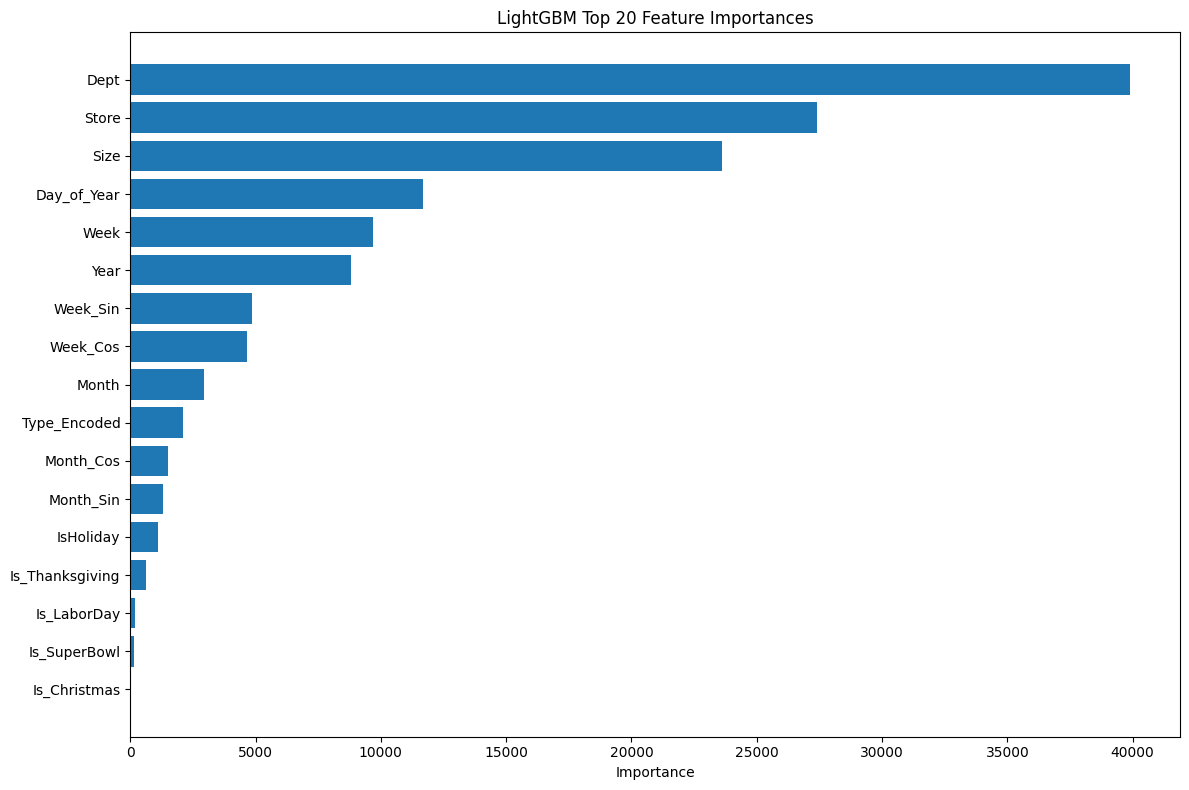


Top 10 features:
     feature  importance
        Dept       39896
       Store       27395
        Size       23633
 Day_of_Year       11702
        Week        9675
        Year        8808
    Week_Sin        4856
    Week_Cos        4643
       Month        2931
Type_Encoded        2119


In [ ]:
lgb_model = final_pipeline.named_steps['model']

importances = pd.DataFrame({
    'feature': BEST_FEATURES,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importances['feature'].head(20)[::-1], importances['importance'].head(20)[::-1])
plt.title('LightGBM Top 20 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances.head(10).to_string(index=False))

## 12. შეჯამება

LightGBM დასრულდა MLflow-ს 5 run-ით, იმავე სტრუქტურით, რითაც XGBoost. Custom `WalmartPreprocessor` (sklearn Transformer, Pipeline-ში) პირდაპირ იღებს raw CSV-ს და აბრუნებს პროგნოზებს.

---

### შედეგები

| ეტაპი | შედეგი |
|---|---|
| **Feature Selection** | გაიმარჯვა `core` ნაკრებმა (17 feature) — Baseline WMAE: 2826.43 |
| **5-fold TimeSeriesSplit CV** | WMAE: 3787.16 ± 786.35 |
| **Optuna Tuning (30 trial)** | საბოლოო ვალიდაციის WMAE: **1098.93** |
| **Model Registry** | დარეგისტრირდა `walmart_lightgbm` v1 |

---

### საინტერესო მიგნება — Feature Selection

XGBoost-ის მსგავსად, `core` ნაკრებმა (მხოლოდ თარიღი + მაღაზიის მეტამონაცემები) აჯობა `all` ნაკრებს, რომელიც მოიცავდა ტემპერატურას, საწვავის ფასს, CPI-ს, უმუშევრობასა და MarkDown-ებს. ორივე tree-based მოდელი ერთსა და იმავე დასკვნამდე მივიდა — ეს ეკონომიკური ცვლადები Walmart-ის ამოცანაში მხოლოდ noise-ს ქმნიდა.

---

### LightGBM vs XGBoost

| მოდელი | WMAE |
|---|---|
| **XGBoost** | **769.75** |
| LightGBM | 1098.93 |

ორივე მოდელი ახლოს არის, მაგრამ XGBoost-მა Walmart-ისთვის უკეთესი შედეგი აჩვენა. LightGBM-ის leaf-wise growth ხშირად უპირატესია დიდ datasets-ებზე, მაგრამ აქ ეს არ გამოვლინდა — XGBoost-ის შედარებით ფრთხილი level-wise growth უკეთ უმკლავდება Walmart-ის მონაცემებს, სადაც Store/Dept კომბინაციები მკაფიოდაა სეგმენტირებული.